# CÓDIGOS PARA LA VISUALIZACIÓN DE DATOS DEL TFG: AMPLIACIÓN DEL TRANVÍA EN MURCIA

## José Francisco Noguera Galián
## 2025/2026

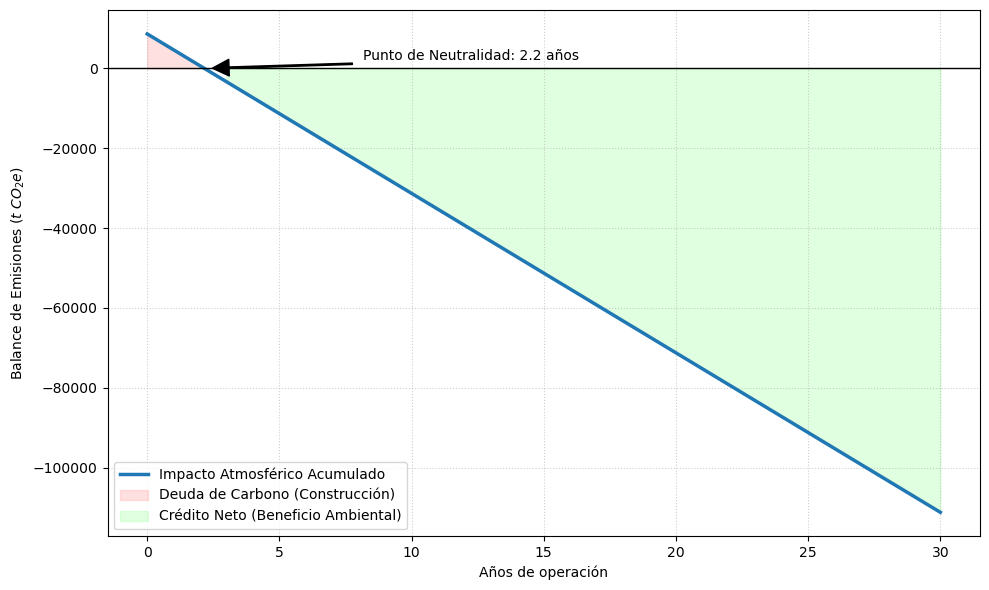

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Parámetros de emisiones (Valores finales calculados)
emisiones_construccion = 8646.20    # t CO2e
ahorro_neto_anual = 3995.39      # t CO2e/año (Evitadas - Operación)
credito_reciclaje = 2527.46         # t CO2e (Módulo D en año 50)

# 2. Simulación temporal (55 años)
anos = np.arange(0, 31)
balance = [emisiones_construccion] # Empezamos con la deuda de construcción

for t in range(1, 31):
    nuevo_valor = balance[-1] - ahorro_neto_anual
    # Al final de la vida útil (año 50) sumamos el crédito por reciclaje
    if t == 50:
        nuevo_valor -= credito_reciclaje
    balance.append(nuevo_valor)

# 3. Generación de la gráfica
plt.figure(figsize=(10, 6))
plt.plot(anos, balance, color='#1f77b4', linewidth=2.5, label='Impacto Atmosférico Acumulado')

# Colorear zonas de deuda (rojo) y crédito (verde)
plt.fill_between(anos, balance, 0, where=(np.array(balance) > 0), color='#ff9999', alpha=0.3, label='Deuda de Carbono (Construcción)')
plt.fill_between(anos, balance, 0, where=(np.array(balance) <= 0), color='#99ff99', alpha=0.3, label='Crédito Neto (Beneficio Ambiental)')

# Estética de la gráfica
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Años de operación')
plt.ylabel(r'Balance de Emisiones ($t\ CO_2e$)')
plt.grid(True, linestyle=':', alpha=0.6)

# Cálculo y anotación del Punto de Neutralidad (Payback)
payback = emisiones_construccion / ahorro_neto_anual
plt.annotate(f'Punto de Neutralidad: {payback:.1f} años', 
             xy=(payback, 0), xytext=(payback + 6, 2000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.legend()
plt.tight_layout()
plt.savefig('grafica_amortizacion_carbono.png')
plt.show()

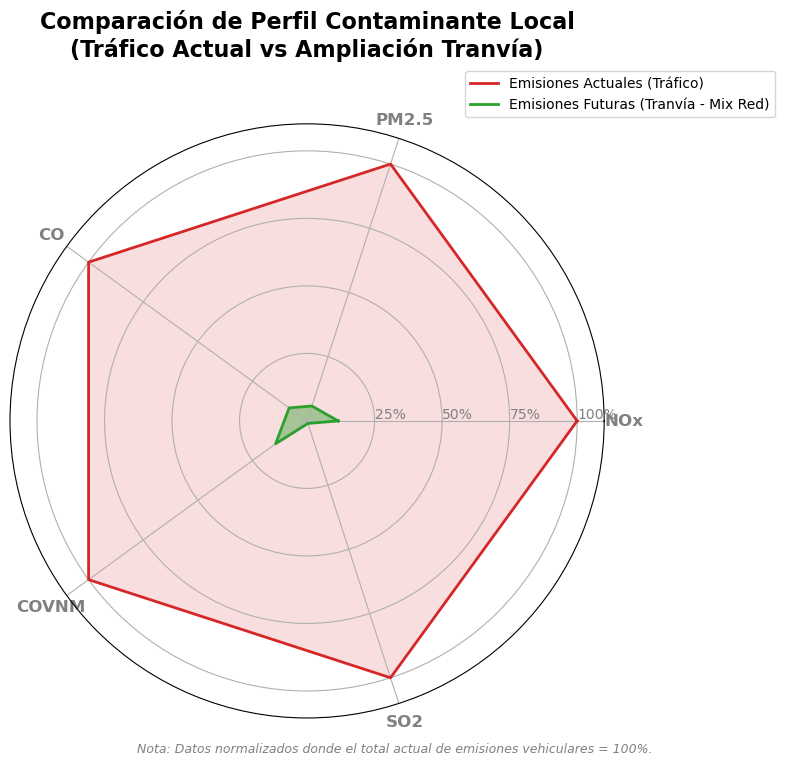

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURACIÓN DE DATOS (Ajusta aquí tus valores finales si cambian) ---
# Nombres de los contaminantes (Añadido SO2)
labels = ['NOx', 'PM2.5', 'CO', 'COVNM', 'SO2']
num_vars = len(labels)

# Emisiones Actuales Totales (Coches+Motos) -> Normalizadas al 100% (valor 1)
# Usamos 1 como referencia para el borde exterior.
data_actual = np.ones(num_vars) 

# Emisiones Futuras con Tranvía (Mix Eléctrico) -> Expresadas como % de la actual
# Añadido 0.990 (99%) para SO2 al final del array
reducciones = np.array([0.885, 0.942, 0.918, 0.856, 0.990]) # % de reducción
data_tram = 1 - reducciones # % de emisión residual

# Cierras el bucle de datos para el polígono del radar
data_actual = np.concatenate((data_actual, [data_actual[0]]))
data_tram = np.concatenate((data_tram, [data_tram[0]]))
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Cierras el bucle de ángulos

# --- 2. INICIALIZACIÓN DE LA GRÁFICA ---
fig, ax = plt.figure(figsize=(8, 8), dpi=100), plt.subplot(polar=True)

# Dibujas la red de la araña
plt.xticks(angles[:-1], labels, color='grey', size=12, fontweight='bold')

# Configuras el eje Y (porcentajes)
ax.set_rlabel_position(0)
plt.yticks([0.25, 0.50, 0.75, 1.0], ["25%", "50%", "75%", "100%"], color="grey", size=10)
plt.ylim(0, 1.1) # Un poco más del 100% para que no toque el borde

# --- 3. DIBUJAR LOS DATOS ---

# Área 1: Emisiones Actuales Tráfico (Rojo - Peligro)
ax.plot(angles, data_actual, linewidth=2, linestyle='solid', color='#d62728', label='Emisiones Actuales (Tráfico)')
ax.fill(angles, data_actual, color='#d62728', alpha=0.15)

# Área 2: Emisiones Futuras Tranvía (Verde - Solución)
ax.plot(angles, data_tram, linewidth=2, linestyle='solid', color='#2ca02c', label='Emisiones Futuras (Tranvía - Mix Red)')
ax.fill(angles, data_tram, color='#2ca02c', alpha=0.4)

# --- 4. DETALLES FINALES ---
plt.title('Comparación de Perfil Contaminante Local\n(Tráfico Actual vs Ampliación Tranvía)', size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

# Añades nota de normalización
fig.text(0.5, 0.02, 'Nota: Datos normalizados donde el total actual de emisiones vehiculares = 100%.', 
         ha='center', size=9, style='italic', color='grey')

plt.tight_layout()
plt.show()

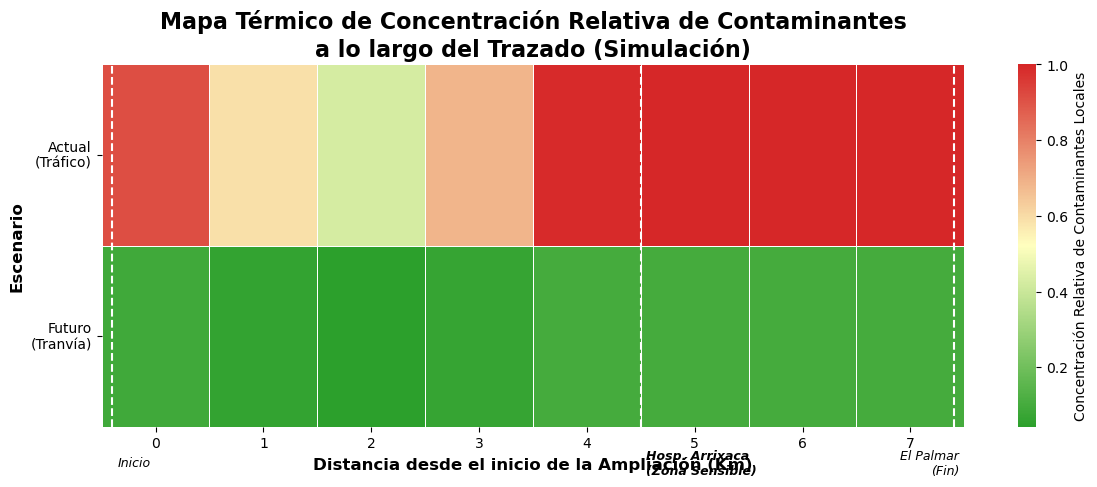

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# --- 1. CONFIGURACIÓN DE DATOS ESPACIALES (Simulación Científica) ---
kilometros = np.linspace(0, 8, 100) # 100 puntos a lo largo de los 8 km
distancia_bins = np.arange(0, 9, 1) # Bins de 1 km para el heatmap

# Definimos puntos calientes de tráfico actual (picos de concentración)
hotspots = [0, 5, 8] # Inicio, Hospital Arrixaca (Km 5), Fin El Palmar (Km 8)
intensidad_hotspot = [0.8, 1.0, 0.9] # Picos de intensidad relativa (0 a 1)

# Función para simular dispersión Gaussiana simple cerca de hotspots
def simular_contaminacion_actual(dist, hspots, intensities):
    pollution = np.ones_like(dist) * 0.2 # Nivel base de contaminación de fondo
    for h, i in zip(hspots, intensities):
        # Gaussiana: intensidad * exp(-(dist-punto)^2 / dispersión^2)
        pollution += i * np.exp(-(dist - h)**2 / (2 * 1.2**2)) 
    return np.clip(pollution, 0, 1) # Limitamos de 0 a 1

# Calculamos intensidades
intensidad_actual = simular_contaminacion_actual(kilometros, hotspots, intensidad_hotspot)
intensidad_futura = intensidad_actual * 0.1 # Reducción drástica uniforme del 90%

# Agrupamos datos en bins de 1km para visualización en Heatmap
df = pd.DataFrame({'Km': kilometros, 'Actual': intensidad_actual, 'Futura': intensidad_futura})
df['Km_Bin'] = pd.cut(df['Km'], bins=distancia_bins, labels=distancia_bins[:-1])
heatmap_data = df.groupby('Km_Bin')[['Actual', 'Futura']].mean().T # Transponemos

# --- 2. CONFIGURACIÓN DE LA GRÁFICA ---
# Mapa de colores personalizado (Rojo intenso -> Amarillo -> Verde suave)
colors = ["#2ca02c", "#ffffbf", "#d62728"] # Verde, Amarillo, Rojo
cmap_rdylgn = LinearSegmentedColormap.from_list("custom_rdylgn", colors)

plt.figure(figsize=(12, 5), dpi=100)

# Dibujamos el Heatmap Lineal
sns.heatmap(heatmap_data, cmap=cmap_rdylgn, cbar=True, annot=False, 
            linewidths=.5, linecolor='white', square=False,
            cbar_kws={'label': 'Concentración Relativa de Contaminantes Locales'})

# --- 3. DETALLES FINALES Y ANOTACIONES ---
plt.title('Mapa Térmico de Concentración Relativa de Contaminantes\na lo largo del Trazado (Simulación)', size=16, fontweight='bold')
plt.ylabel('Escenario', fontweight='bold', size=12)
plt.xlabel('Distancia desde el inicio de la Ampliación (Km)', fontweight='bold', size=12)
plt.yticks([0.5, 1.5], ['Actual\n(Tráfico)', 'Futuro\n(Tranvía)'], rotation=0)

# Añadimos marcadores geográficos clave
# Km 0
plt.axvline(x=0.1, color='white', linestyle='--', linewidth=1.5)
plt.text(0.15, 2.2, 'Inicio', color='black', ha='left', va='center', size=9, style='italic')

# Km 5 - Hospital Arrixaca
plt.axvline(x=5.0, color='white', linestyle='--', linewidth=1.5)
plt.text(5.05, 2.2, 'Hosp. Arrixaca\n(Zona Sensible)', color='black', ha='left', va='center', size=9, style='italic', fontweight='bold')

# Km 8 - El Palmar
plt.axvline(x=7.9, color='white', linestyle='--', linewidth=1.5)
plt.text(7.95, 2.2, 'El Palmar\n(Fin)', color='black', ha='right', va='center', size=9, style='italic')

plt.tight_layout()
plt.show()

In [2]:
%pip install contextily pyproj scipy matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install aiosignal==1.3.1

  Attempting uninstall: aiosignal
    Found existing installation: aiosignal 1.4.0
    Uninstalling aiosignal-1.4.0:
      Successfully uninstalled aiosignal-1.4.0
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiohttp 3.13.5 requires aiosignal>=1.4.0, but you have aiosignal 1.3.1 which is incompatible.


In [1]:
"""
Ejecutar desde la carpeta del TFG:
    pip install contextily pyproj scipy matplotlib numpy
    python generar_dispersion_mapa.py

Genera: dispersion_NOx_PM25.png  (con mapa OSM de fondo)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter
from matplotlib.gridspec import GridSpec
import contextily as ctx
from pyproj import Transformer
from collections import defaultdict

# ── Rosa de vientos real Murcia (Meteoblue ERA5T) ─────────────────
h16 = {'N':150,'NNE':250,'NE':700,'ENE':450,'E':300,'ESE':250,
       'SE':200,'SSE':150,'S':100,'SSW':350,'SW':600,'WSW':450,
       'W':400,'WNW':500,'NW':600,'NNW':585}
map8 = {'N':'N','NNE':'NE','NE':'NE','ENE':'E','E':'E','ESE':'SE',
        'SE':'SE','SSE':'S','S':'S','SSW':'SW','SW':'SW','WSW':'W',
        'W':'W','WNW':'NW','NW':'NW','NNW':'N'}
h8 = defaultdict(float)
for d, h in h16.items():
    h8[map8[d]] += h
order8 = ['N','NE','E','SE','S','SW','W','NW']
angles  = np.array([0,45,90,135,180,225,270,315], dtype=float)
freqs_h = np.array([h8[d] for d in order8])
freqs   = freqs_h / freqs_h.sum()

# ── Modelo gaussiano de dispersión ────────────────────────────────
u = 3.0; z_rec = 1.5
n_cars=2308; n_motos=286; dias=300; L_m=8000.0
q_NOx  = (n_cars*0.437  + n_motos*0.200 )*2*(L_m/1000)*dias/365/86400/L_m
q_PM25 = (n_cars*0.0432 + n_motos*0.015 )*2*(L_m/1000)*dias/365/86400/L_m

SY_MIN = 30.0
def sig_y(x): return np.maximum(0.128*np.maximum(x,1.0)**0.905, SY_MIN)
def sig_z(x): return 0.093*np.maximum(x,1.0)**0.723

# ── Trazado real del corredor (polilínea con curva para evitar El Palmar) ──
# Waypoints en coordenadas locales (km), origen = Plaza Circular
# Estimados a partir del trazado real (CalcMaps + Scribble Maps)
wp_E = np.array([ 0.00, -1.00, -1.85, -2.65, -3.15, -2.60, -2.10, -2.25, -2.40])
wp_N = np.array([ 0.00, -1.50, -3.00, -4.50, -5.80, -6.50, -7.00, -7.30, -7.50])

# Calcular distancia acumulada a lo largo de la polilínea
dE = np.diff(wp_E); dN = np.diff(wp_N)
seg_len = np.sqrt(dE**2 + dN**2)           # longitud de cada segmento (km)
s_wp = np.concatenate([[0], np.cumsum(seg_len)])  # distancia acumulada en waypoints
L_poly = s_wp[-1]                           # longitud total real (km)

# Interpolar N_pts fuentes uniformemente distribuidas a lo largo de la polilínea
N_pts = 200
s_vals = np.linspace(0, L_poly, N_pts)     # distancias en km
src_E  = np.interp(s_vals, s_wp, wp_E) * 1000   # metros
src_N  = np.interp(s_vals, s_wp, wp_N) * 1000   # metros
L_m    = L_poly * 1000                     # longitud real en metros

# Waypoints de extremos para dibujar el corredor
corr_E_wp = wp_E; corr_N_wp = wp_N

xe = np.linspace(-4.2, 1.5, 240)
yn = np.linspace(-8.5,  0.8, 220)
XG, YG   = np.meshgrid(xe, yn)
XGm, YGm = XG*1000, YG*1000

def field(q_line):
    q_pt = q_line * L_m / N_pts
    C = np.zeros_like(XGm)
    for wd, wf in zip(angles, freqs):
        phi = np.radians(wd + 180)
        wx, wy = np.sin(phi), np.cos(phi)
        Cw = np.zeros_like(XGm)
        for start in range(0, N_pts, 50):
            se3 = src_E[start:start+50][:,None,None]
            sn3 = src_N[start:start+50][:,None,None]
            dE  = XGm[None] - se3
            dN  = YGm[None] - sn3
            dx  =  dE*wx + dN*wy
            dy  = -dE*wy + dN*wx
            mask = dx > 5.0
            xd  = np.where(mask, dx, 1.0)
            sy  = sig_y(xd); sz = sig_z(xd)
            Cw += np.where(mask,
                q_pt/(2*np.pi*sy*sz*u)*
                np.exp(-dy**2/(2*sy**2))*
                2*np.exp(-z_rec**2/(2*sz**2)), 0.0).sum(axis=0)
        C += wf * Cw
    return gaussian_filter(C * 1e6 * 4, sigma=0.8)

print("Calculando campo NOx...")
C_NOx  = field(q_NOx)
print("Calculando campo PM2.5...")
C_PM25 = field(q_PM25)
print(f"NOx max={C_NOx.max():.3f}  PM2.5 max={C_PM25.max():.4f}")

# ── Conversión local (km) → lat/lon → Web Mercator ───────────────
lat0, lon0 = 37.9868, -1.1303          # Plaza Circular, Murcia
km_per_lat = 111.32
km_per_lon = 111.32 * np.cos(np.radians(lat0))

lat_grid = lat0 + YG / km_per_lat
lon_grid = lon0 + XG / km_per_lon

tr = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
X_wm, Y_wm = tr.transform(lon_grid, lat_grid)

# Convertir toda la polilínea a Web Mercator
corr_lon = lon0 + corr_E_wp / km_per_lon
corr_lat = lat0 + corr_N_wp / km_per_lat
cE_wm, cN_wm = tr.transform(corr_lon, corr_lat)

# ── Figura ────────────────────────────────────────────────────────
# Aspecto geográfico: dominio ~4.5 km ancho × ~9.3 km alto → ratio ~0.48
# Con dos paneles + colorbars → figsize proporcional
fig = plt.figure(figsize=(12, 9))
plt.rcParams.update({'font.size': 11})
gs = GridSpec(1, 2, figure=fig, wspace=0.28,
              left=0.04, right=0.96, top=0.91, bottom=0.04)
axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])]

def draw(ax, C, title, cblabel, cmap, vmin, vmax, cb_ticks, iso_levels):
    norm  = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    Cplot = np.where(C < vmin, vmin, C)
    # 1. Límites ANTES de add_basemap
    ax.set_xlim(X_wm.min(), X_wm.max())
    ax.set_ylim(Y_wm.min(), Y_wm.max())
    ax.set_aspect('equal')
    # 2. Mapa OSM de fondo (opaco)
    ctx.add_basemap(ax, crs='EPSG:3857',
                    source=ctx.providers.OpenStreetMap.Mapnik,
                    zoom=13, alpha=1.0, zorder=0)
    # 3. Concentración semitransparente
    pm = ax.pcolormesh(X_wm, Y_wm, Cplot, cmap=cmap, norm=norm,
                       shading='gouraud', alpha=0.38, zorder=2)
    # 4. Colorbar opaca (independiente del alpha de los datos)
    cb = fig.colorbar(pm, ax=ax, label=cblabel, shrink=0.85, pad=0.01)
    cb.set_ticks(cb_ticks)
    cb.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    cb.ax.tick_params(labelsize=9)
    cb.solids.set_alpha(1.0)   # colorbar opaca aunque los datos sean transparentes
    # 5. Isolíneas
    cs = ax.contour(X_wm, Y_wm, C, levels=iso_levels,
                    colors='white', linewidths=1.2, zorder=3)
    ax.clabel(cs, fmt='%.1f', fontsize=12, inline=True,
              inline_spacing=5, colors='white')
    # 6. Corredor
    ax.plot(cE_wm, cN_wm, color='white', lw=5,
            solid_capstyle='round', zorder=4)
    ax.plot(cE_wm, cN_wm, color='#1a5fa8', lw=2.2,
            ls='--', label='Corredor tranvía', zorder=5)
    ax.scatter([cE_wm[0], cE_wm[-1]], [cN_wm[0], cN_wm[-1]],
               color='#1a5fa8', s=35, zorder=6)
    ax.text(cE_wm[0]+200, cN_wm[0]+200, 'Plaza Circular',
            fontsize=7.5, color='#1a5fa8', fontweight='bold', zorder=7)
    ax.text(cE_wm[-1]+200, cN_wm[-1]-350, 'Hospital\nArrixaca',
            fontsize=7.5, color='#1a5fa8', fontweight='bold', zorder=7)
    ax.set_title(title, fontsize=11, pad=6)
    ax.legend(loc='upper right', fontsize=8)
    ax.tick_params(labelbottom=False, labelleft=False)

draw(axes[0], C_NOx,
     r'$\Delta C_{NO_x}$ (μg·m$^{-3}$)',
     r'$\Delta C_{NO_x}$ (μg·m$^{-3}$)', 'YlOrRd',
     vmin=0.1, vmax=5.0,
     cb_ticks=[0.1, 0.2, 0.5, 1.0, 2.0, 5.0],
     iso_levels=[0.5, 1, 2, 3, 4, 5])

draw(axes[1], C_PM25,
     r'$\Delta C_{PM_{2.5}}$ (μg·m$^{-3}$)',
     r'$\Delta C_{PM_{2.5}}$ (μg·m$^{-3}$)', 'YlGn',
     vmin=0.01, vmax=0.5,
     cb_ticks=[0.01, 0.02, 0.05, 0.1, 0.2, 0.5],
     iso_levels=[0.1, 0.2, 0.3, 0.4, 0.5])

fig.suptitle(
    'Mejora de calidad del aire — corredor Plaza Circular → Hospital Arrixaca'
    , fontsize=10)

out = 'dispersion_NOx_PM25.png'
plt.savefig(out, dpi=160)
plt.close()
print(f"Figura guardada: {out}")

Calculando campo NOx...
Calculando campo PM2.5...
NOx max=10.159  PM2.5 max=0.9913
Figura guardada: dispersion_NOx_PM25.png
